In [1]:
import json
import os
import random
from glob import glob
from time import time

import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from IPython.display import clear_output

from models.simple_classifier import model as M, config as C, analysis as A
from data_readers import name_map as N, data_loader as D
from importlib import reload

tqdm.pandas()
_=reload(M), reload(C), reload(N), reload(D)

In [2]:
dummy_inputs, dummy_labels = A.get_dummy_xy(device="cuda")
{f"{k:>11}": f"{str(tuple(v.shape)):<15}" for k, v in dummy_inputs.items()}

{'      radar': '(16, 24, 64, 4)', '   infrared': '(16, 256, 6, 7)'}

In [ ]:
table = {
    "model_type" : [],
    "n_params"   : [],
    "mutations"  : [],
    "infer_times": [],
    "train_times": [],
}

In [ ]:
# table = pd.read_csv("model_variants.csv", converters={"mutations": json.loads, "infer_times": json.loads, "train_times": json.loads}).to_dict("list")
# {k:v[-3:] for k,v in table.items()}

In [ ]:
assert len({len(v) for v in table.values()}) == 1, "All lists in the table must have the same length."
for rep in range(15):
    for _ in tqdm(range(30), desc=f"rep: {rep+1}"):
        model_type = random.sample(["radar", "infrared", "fancy_infrared"], k=1, counts=[2, 1, 1])[0]
        config, base, params = C.random_model_variant(base_config=None, model_type=model_type, n=None)
        model = M.get_model(model_type, config[model_type])
        infer_ts, train_ts = A.run_model_timer(model.to("cuda"), model_type, config, dummy_inputs, dummy_labels, multiplier=1)
        table["n_params"   ].append(model.n_params)
        table["model_type" ].append(model_type)
        table["mutations"  ].append(params)
        table["infer_times"].append(infer_ts)
        table["train_times"].append(train_ts)
        del model

    df = pd.DataFrame(table)
    df["mutations"] = df.mutations.apply(lambda x: json.dumps(x,sort_keys=True))
    df = df.drop_duplicates("mutations")
    df.to_csv("model_variants.csv", index=False)

    clear_output(wait=True)
    print(df.shape)
    display(df.sample(3))
    df["bucket"] = df.n_params.apply(np.log10).round(1) #+np.random.uniform(-0.025, 0.025)
    plt.figure(figsize=(12, 6))
    df.groupby(["model_type", "bucket"]).size().unstack().T.plot(ax=plt.gca(), style=".-", linewidth=2)  # fill_value=0
    plt.axhline(y=1, color="black", linestyle="--")
    plt.ylabel("frequency")
    plt.grid(True)
    ax=plt.twinx()
    df["mean_infer_time"] = df.infer_times.apply(lambda x: np.mean(x))
    df["mean_train_time"] = df.train_times.apply(lambda x: np.mean(x))
    tdf = (df.groupby(["model_type", "bucket"])[["mean_infer_time", "mean_train_time"]].mean()).unstack(level=0)
    tdf.plot(ax=ax, style=".--", alpha=0.7)
    plt.ylim(0, tdf.quantile([0.998]).mean(axis=1).values[0]*1.1)
    plt.ylabel("Time (ms)")
    plt.show()

In [ ]:
df = pd.read_csv("model_variants.csv", converters={"infer_times": json.loads, "train_times": json.loads})
df["avg_infer_t"] = df.infer_times.apply(np.median)
df["avg_train_t"] = df.train_times.apply(np.median)
quantile = 0.99
aitq = df["avg_train_t"].quantile([quantile]).values[0]
attq = df["avg_train_t"].quantile([quantile]).values[0]
mask  = df["avg_infer_t"] > aitq
mask |= df["avg_train_t"] > attq
time_per_param = ((df.avg_train_t + df.avg_infer_t) / (df.n_params.apply(np.log10)))
mask |= time_per_param > time_per_param.quantile([quantile]).values[0]
time_per_param = ((df.avg_train_t + df.avg_infer_t) / (df.n_params.pow(0.5)))
mask |= time_per_param > time_per_param.quantile([quantile]).values[0]
mask.value_counts()

In [ ]:
for i, row in tqdm(df[mask].iterrows(), total=mask.sum()):
    config = C.apply_params_to_config(C.baseline_model_config(), json.loads(row.mutations))
    model = M.get_model(row.model_type, config[row.model_type]).to("cuda")
    assert model.n_params == row.n_params, f"Model parameters mismatch: {model.n_params} != {row.n_params}"
    infer_ts, train_ts = A.run_model_timer(model, row.model_type, config, dummy_inputs, dummy_labels, multiplier=1)
    row["infer_times"].extend(infer_ts)
    row["train_times"].extend(train_ts)

train_to_infer_ratio                                           \
                              count      mean        std       min       25%   
model_type                                                                     
fancy_infrared               2746.0  3.866850   1.825544  0.212382  3.313083   
infrared                     2606.0  6.584654  10.015450  0.223381  3.148635   
radar                        4648.0  4.144631   1.386488  0.253915  3.581076   

                                               
                     50%       75%        max  
model_type                                     
fancy_infrared  3.643349  4.114964  48.472613  
infrared        3.483733  4.279731  80.289221  
radar           3.968013  4.492348  55.075507

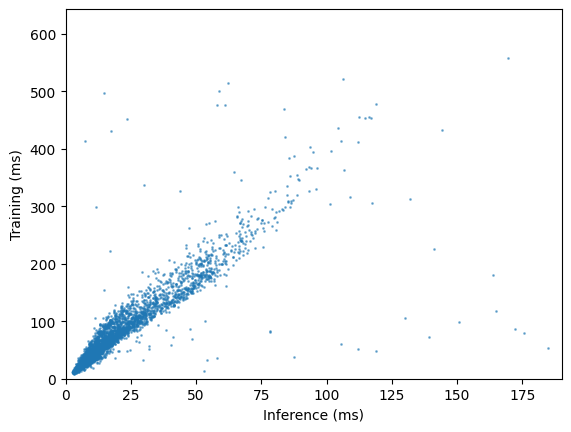

In [134]:
mask = df["model_type"] == "radar"
# mask = df["model_type"] == "infrared"
# mask = df["model_type"] == "fancy_infrared"
plt.scatter(df[mask]["avg_infer_t"], df[mask]["avg_train_t"], alpha=0.5, s=1)
plt.xlim(0, df["avg_infer_t"].quantile([0.998]).values[0])
plt.ylim(0, df["avg_train_t"].quantile([0.998]).values[0])
plt.xlabel("Inference (ms)")
plt.ylabel("Training (ms)")
df["train_to_infer_ratio"] = df["avg_train_t"] / df["avg_infer_t"]
df[["model_type", "train_to_infer_ratio"]].groupby("model_type").describe()

In [ ]:
# print(config)
# model = M.get_model(model_type, config[model_type])
# infer_ts, train_ts = A.run_model_timer(model.to("cuda"), model_type, config, dummy_inputs, dummy_labels, multiplier=1)

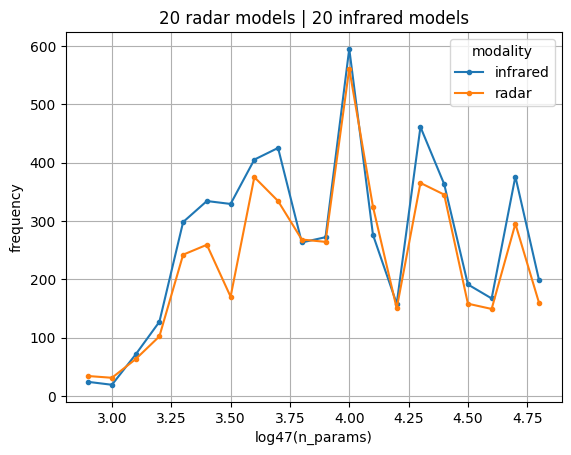

In [175]:
df = pd.read_csv("model_variants.csv", converters={"infer_times": json.loads, "train_times": json.loads,
    # "mutations": json.loads,
})
bucket_log_base = 47
if "modality" not in df.columns:
    df["modality"] = (df.model_type == "radar").map({True: "radar", False: "infrared"})
if "bucket" not in df.columns:
    df["bucket"] = df.n_params.apply(lambda x: np.log(x)/np.log(bucket_log_base)).round(1)

df["avg_infer_t"] = df.infer_times.apply(np.median)
df["avg_train_t"] = df.train_times.apply(np.median)

groups = df.groupby(["modality", "bucket"])
groups.size().unstack().T.plot(style=".-")
plt.title(f"{sum(i[0]=='radar' for i,g in groups)} radar models | {sum(i[0]=='infrared' for i,g in groups)} infrared models")
plt.ylabel("frequency")
plt.xlabel(f"log{bucket_log_base}(n_params)")
plt.grid(True)

In [200]:
def model_from_row(row:pd.Series):
    config = C.apply_params_to_config(C.baseline_model_config(), json.loads(row.mutations))
    model = M.get_model(row.model_type, config[row.model_type])
    return model

model = model_from_row(df.iloc[5132])
print(dummy_inputs["radar"].shape)
model(dummy_inputs["radar"]).shape

torch.Size([16, 24, 64, 4])
BERT Input shape: torch.Size([384, 64, 4])
BERT Input shape after projection: torch.Size([384, 64, 32])
BERT input shape: torch.Size([384, 64, 32])
BERT output shape: torch.Size([384, 64, 32])
BERT pooled output shape: torch.Size([384, 32])
LLAMA Input shape: torch.Size([16, 24, 32])
LLAMA Input shape after projection: torch.Size([16, 24, 128])
LLAMA input shape: torch.Size([16, 24, 128])
LLAMA output shape: torch.Size([16, 24, 128])
LLAMA pooled output shape: torch.Size([16, 128])


torch.Size([16, 2])

In [172]:
groups.sample(1).model_type.value_counts()

model_type
radar             20
fancy_infrared    13
infrared           7
Name: count, dtype: int64

In [3]:
# model_type = "radar"
# config, base, params = C.random_model_variant(base_config=None, model_type=model_type, n=None)
# # variant = {"num_classes": 3, **variant}
# model = M.get_model(model_type, config[model_type])
# exp_log = C.experiment_log()
# exp_log["model_type"] = model_type
# exp_log["n_params"] = model.n_params
# exp_log["model_configs"]["mutations"] = params
# exp_log["model_configs"]["base_config"] = base
# exp_log["model_configs"]["final_config"] = config
# exp_log["n_outputs"] = model.output_dim
# exp_log